In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2925,2025-09-21 03:01:00,click,46,Women,Vogue Women Pink Sunglasses,vogue,4930.0,4437.0,...,Pink,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>This stylish range of vogue sunglasses are ...
1,1,2290,2025-09-21 03:02:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1950.0,1755.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
2,1,1287,2025-09-21 03:05:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1450.0,1305.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
3,1,7226,2025-09-21 03:04:00,click,46,Women,Miami Blues Women Sunglasses,Miami Blues,915.0,713.0,...,Purple,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>NA</p>
4,1,868,2025-09-21 03:17:00,click,46,Women,United Colors of Benetton Women Sunglass,United Colors of Benetton,3450.0,3105.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p><span style=""color: #000000 font-family;"">..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
model_dir = Path(root_dir).joinpath("data/outputs/fashion")

# 모델 객체 초기화
model = Model(model_dir=model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,8890,1,5,"[0, 0, 0, 0, 0]","[Femella, Myntra, Femella, Femella, The Amazin...","[Women, Women, Women, Women, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Red, Pink, Teal, Blue, Teal]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Bottomwear, Bottomwear, Bottomwear, Bottomwea...","[Leggings, Leggings, Leggings, Leggings, Tshirts]","[<UNK>, <UNK>, <UNK>, <UNK>, Regular Fit]","[<UNK>, Casual, <UNK>, <UNK>, Casual]","[click, click, click, click, click]","[4547, 7110, 847, 221, 7875]","[7110, 847, 221, 7875, 1147]"
1,8890,2,5,"[0, 0, 0, 0, 0]","[Rasasi, Nike Fragrances, Femella, Myntra, Fem...","[Men, Men, Women, Women, Women]","[Adults-Men, Adults-Men, Adults-Women, Adults-...","[Blue, Blue, Red, Pink, Teal]","[Spring, Spring, Summer, Summer, Summer]","[2017, 2017, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Personal Care, Personal Care, Apparel, Appare...","[Fragrance, Fragrance, Bottomwear, Bottomwear,...","[Perfume and Body Mist, Perfume and Body Mist,...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, Casual, <UNK>]","[click, wishlist, click, click, click]","[7603, 3344, 4547, 7110, 847]","[3344, 4547, 7110, 847, 221]"
2,8890,3,5,"[0, 0, 0, 0, 0]","[Nike Fragrances, Femella, Myntra, Femella, Fe...","[Men, Women, Women, Women, Women]","[Adults-Men, Adults-Women, Adults-Women, Adult...","[Blue, Red, Pink, Teal, Blue]","[Spring, Summer, Summer, Summer, Summer]","[2017, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Personal Care, Apparel, Apparel, Apparel, App...","[Fragrance, Bottomwear, Bottomwear, Bottomwear...","[Perfume and Body Mist, Leggings, Leggings, Le...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, Casual, <UNK>, <UNK>]","[wishlist, click, click, click, click]","[3344, 4547, 7110, 847, 221]","[4547, 7110, 847, 221, 7875]"
3,8890,4,5,"[0, 0, 0, 0, 0]","[dunhill, Rasasi, Nike Fragrances, Femella, My...","[Men, Men, Men, Women, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Wo...","[Red, Blue, Blue, Red, Pink]","[Spring, Spring, Spring, Summer, Summer]","[2017, 2017, 2017, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Personal Care, Personal Care, Personal Care, ...","[Fragrance, Fragrance, Fragrance, Bottomwear, ...","[Perfume and Body Mist, Perfume and Body Mist,...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, Casual]","[click, click, wishlist, click, click]","[5492, 7603, 3344, 4547, 7110]","[7603, 3344, 4547, 7110, 847]"
4,8890,5,5,"[0, 0, 0, 0, 0]","[Ralph Lauren, dunhill, Rasasi, Nike Fragrance...","[Men, Men, Men, Men, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Orange, Red, Blue, Blue, Red]","[Spring, Spring, Spring, Spring, Summer]","[2017, 2017, 2017, 2017, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Personal Care, Personal Care, Personal Care, ...","[Fragrance, Fragrance, Fragrance, Fragrance, B...","[Perfume and Body Mist, Perfume and Body Mist,...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, wishlist, click]","[4924, 5492, 7603, 3344, 4547]","[5492, 7603, 3344, 4547, 7110]"
5,8890,6,5,"[0, 0, 0, 0, 0]","[The Amazing Spiderman, John Players, LOCOMOTI...","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Teal, Grey, Grey, Black, Black]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Accessories]","[Topwear, Topwear, Topwear, Topwear, Belts]","[Tshirts, Tshirts, Tshirts, Tshirts, Belts]","[Regular Fit, Slim Fit, Regular Fit, Regular F...","[Casual, Casual, Casual, <UNK>, Formal]","[cli

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 8890,
 'user_rn': 6,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['The Amazing Spiderman',
  'John Players',
  'LOCOMOTIVE',
  'Mark Taylor',
  'Peter England'],
 'gender': ['Men', 'Men', 'Men', 'Men', 'Men'],
 'age_group': ['Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Men'],
 'base_color': ['Teal', 'Grey', 'Grey', 'Black', 'Black'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Summer'],
 'year': ['2012', '2012', '2012', '2012', '2012'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Apparel',
  'Apparel',
  'Apparel',
  'Apparel',
  'Accessories'],
 'sub_category': ['Topwear', 'Topwear', 'Topwear', 'Topwear', 'Belts'],
 'article_type': ['Tshirts', 'Tshirts', 'Tshirts', 'Tshirts', 'Belts'],
 'fit': ['Regular Fit', 'Slim Fit', 'Regular Fit', 'Regular Fit', '<UNK>'],
 'occasion': ['Casual', 'Casual', 'Casual', '<UNK>', 'Formal'],
 'action': ['click', 'click', 'click', 'click', 'wishlist'],
 'i

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'click', 'click', 'click', 'wishlist'],
 'age_group': ['Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Men'],
 'article_type': ['Tshirts', 'Tshirts', 'Tshirts', 'Tshirts', 'Belts'],
 'base_color': ['Teal', 'Grey', 'Grey', 'Black', 'Black'],
 'brand_name': ['The Amazing Spiderman',
                'John Players',
                'LOCOMOTIVE',
                'Mark Taylor',
                'Peter England'],
 'fit': ['Regular Fit', 'Slim Fit', 'Regular Fit', 'Regular Fit', '<UNK>'],
 'gender': ['Men', 'Men', 'Men', 'Men', 'Men'],
 'master_category': ['Apparel', 'Apparel', 'Apparel', 'Apparel', 'Accessories'],
 'occasion': ['Casual', 'Casual', 'Casual', '<UNK>', 'Formal'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Summer'],
 'sub_category': ['Topwear', 'Topwear', 'Topwear', 'Topwear', 'Belts'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'year': ['2012', '2012', '2

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

{'item_vector': [-0.03071621246635914,
                 -0.020398663356900215,
                 0.004875770304352045,
                 -0.05575345456600189,
                 -0.03813737630844116,
                 -0.06603026390075684,
                 -0.013141254894435406,
                 -0.00633785268291831,
                 -0.03334041312336922,
                 -0.07790925353765488,
                 -0.03086959943175316,
                 0.01860829070210457,
                 0.02452821470797062,
                 -0.05125004053115845,
                 0.04421202093362808,
                 -0.0265003964304924,
                 -0.01532672718167305,
                 -0.04020485281944275,
                 -0.017529886215925217,
                 -0.026721255853772163,
                 -0.01604795828461647,
                 0.01808176375925541,
                 0.030674735084176064,
                 -0.05245257169008255,
                 0.028479700908064842,
                 -0.011794

# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{4670: 0.3029983639717102,
 4521: 0.3014960289001465,
 5314: 0.3002578020095825,
 8460: 0.2973012924194336,
 8691: 0.2969198226928711,
 9274: 0.2944645285606384,
 8992: 0.293969988822937,
 26: 0.2937890291213989,
 4201: 0.2929391860961914,
 8300: 0.29237544536590576,
 3183: 0.2922370433807373,
 6002: 0.2891414165496826,
 8725: 0.286787211894989,
 928: 0.28618431091308594,
 858: 0.2851753234863281,
 4151: 0.28480321168899536,
 2359: 0.28396129608154297,
 9356: 0.28395235538482666,
 6395: 0.283899188041687,
 4735: 0.28058910369873047,
 6378: 0.2801194190979004,
 442: 0.276975154876709,
 968: 0.27669060230255127,
 4096: 0.27653515338897705,
 8206: 0.27636051177978516,
 2863: 0.2761189937591553,
 1685: 0.2752591371536255,
 9061: 0.27498841285705566,
 2382: 0.2745465636253357,
 3299: 0.27387022972106934}

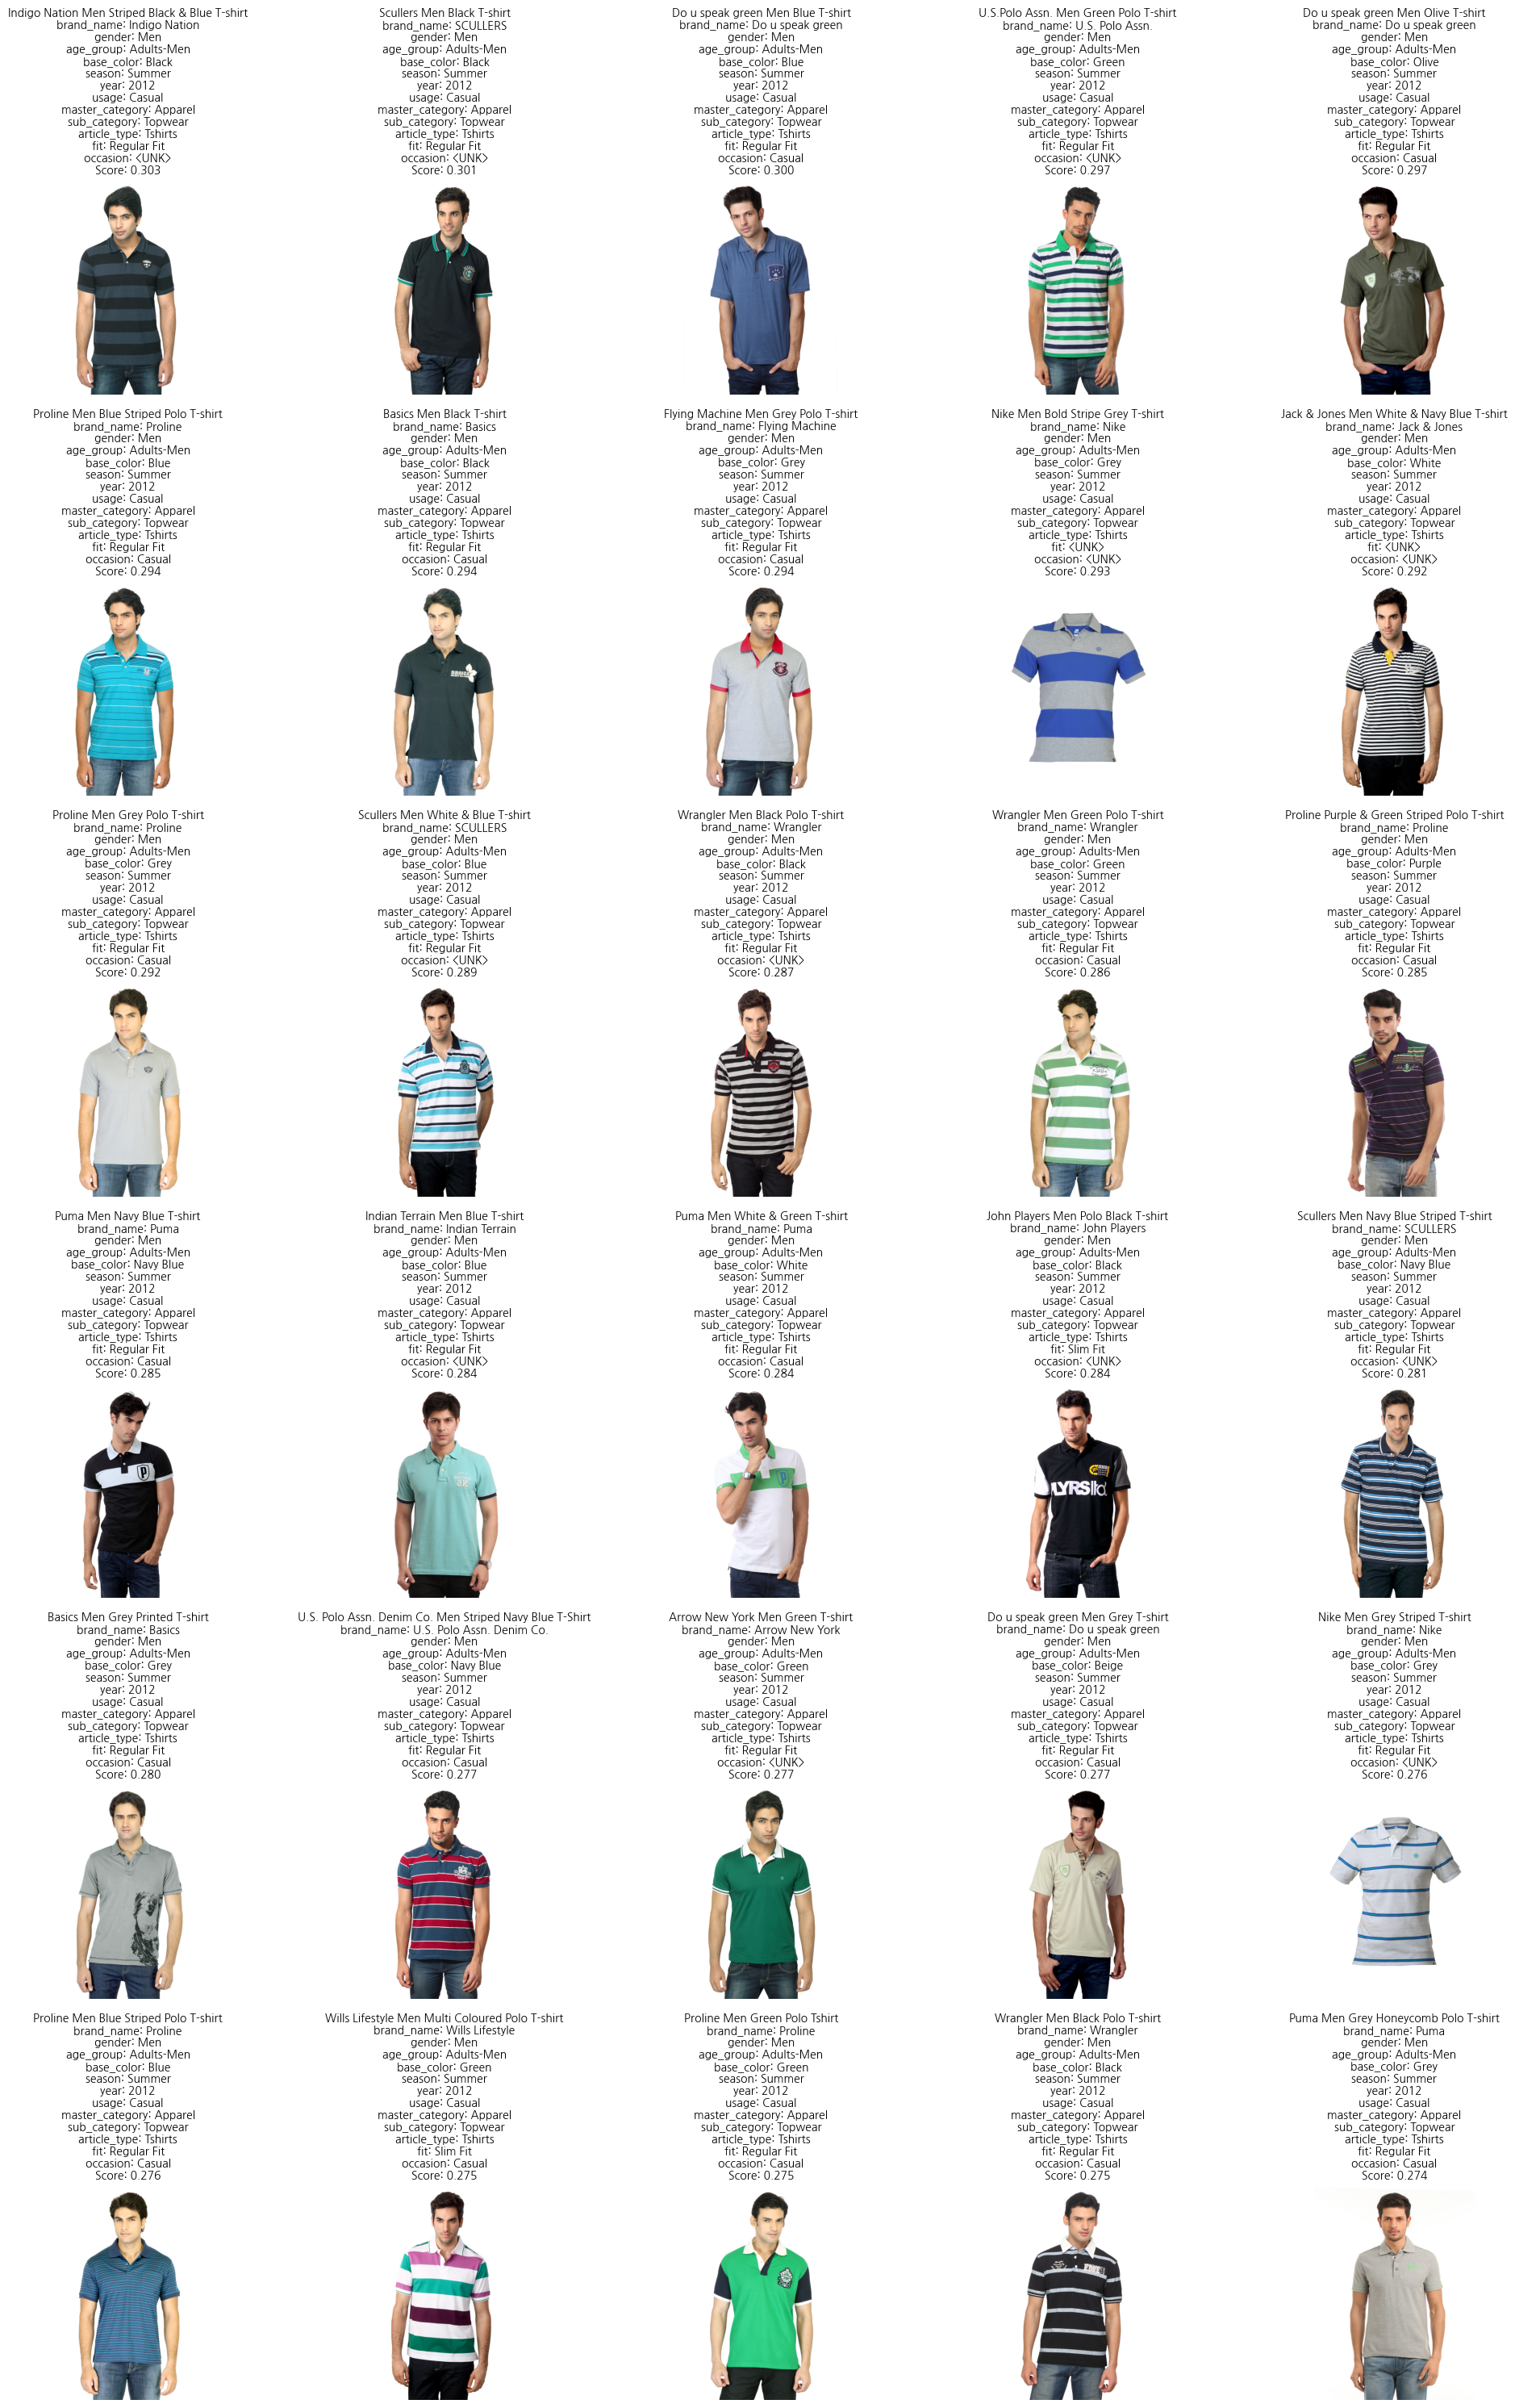

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.base_path.joinpath("images"),
)